# Campus Placement Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,0,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,0,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,0,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,0,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,0,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [4]:
df.shape

(215, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    int64  
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(2), object(7)
memory usage: 25.3+ KB


In [6]:
df.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

## EDA

In [7]:
df['status'].unique()

array(['Placed', 'Not Placed'], dtype=object)

In [8]:
df['status'].value_counts()

Placed        148
Not Placed     67
Name: status, dtype: int64

In [9]:
df.describe()

,sl_no,gender,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,0.353488,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,0.479168,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,0.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,0.000000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,0.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,1.000000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,1.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [10]:
df.columns

Index(['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s',
       'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p',
       'status', 'salary'],
      dtype='object')

## Data Preprocessing

In [11]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,0,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,0,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,0,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,0,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,0,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [12]:
df = df.drop(['sl_no','salary'],axis=1)

In [13]:
df.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,0,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed
1,0,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed
2,0,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed
3,0,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed
4,0,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed


In [14]:
df['ssc_b'].unique()

array(['Others', 'Central'], dtype=object)

In [15]:
df['ssc_b'].value_counts()

Central    116
Others      99
Name: ssc_b, dtype: int64

In [16]:
df['ssc_b'] = df['ssc_b'].map({'Central':1,'Others':0})

In [17]:
df['hsc_b'].unique()

array(['Others', 'Central'], dtype=object)

In [18]:
df['hsc_b'].value_counts()

Others     131
Central     84
Name: hsc_b, dtype: int64

In [19]:
df['hsc_b'] = df['hsc_b'].map({'Central':1,'Others':0})

In [20]:
df.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,0,67.00,0,91.00,0,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed
1,0,79.33,1,78.33,0,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed
2,0,65.00,1,68.00,1,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed
3,0,56.00,1,52.00,1,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed
4,0,85.80,1,73.60,1,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed


In [21]:
df['hsc_s'].unique()

array(['Commerce', 'Science', 'Arts'], dtype=object)

In [22]:
df['hsc_s'] = df['hsc_s'].map({'Commerce':1,'Science':2,'Arts':0})

In [23]:
df['degree_t'].unique()

array(['Sci&Tech', 'Comm&Mgmt', 'Others'], dtype=object)

In [24]:
df['degree_t'] = df['degree_t'].map({'Sci&Tech':2,'Comm&Mgmt':1,'Others':0})

In [25]:
df.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,0,67.00,0,91.00,0,1,58.00,2,No,55.0,Mkt&HR,58.80,Placed
1,0,79.33,1,78.33,0,2,77.48,2,Yes,86.5,Mkt&Fin,66.28,Placed
2,0,65.00,1,68.00,1,0,64.00,1,No,75.0,Mkt&Fin,57.80,Placed
3,0,56.00,1,52.00,1,2,52.00,2,No,66.0,Mkt&HR,59.43,Not Placed
4,0,85.80,1,73.60,1,1,73.30,1,No,96.8,Mkt&Fin,55.50,Placed


In [26]:
df['workex'].unique()

array(['No', 'Yes'], dtype=object)

In [27]:
df['workex'] = df['workex'].map({'Yes':1,'No':0})

In [28]:
df['specialisation'].unique()

array(['Mkt&HR', 'Mkt&Fin'], dtype=object)

In [29]:
df['specialisation'] = df['specialisation'].map({'Mkt&HR':1,'Mkt&Fin':0})

In [30]:
df.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,0,67.00,0,91.00,0,1,58.00,2,0,55.0,1,58.80,Placed
1,0,79.33,1,78.33,0,2,77.48,2,1,86.5,0,66.28,Placed
2,0,65.00,1,68.00,1,0,64.00,1,0,75.0,0,57.80,Placed
3,0,56.00,1,52.00,1,2,52.00,2,0,66.0,1,59.43,Not Placed
4,0,85.80,1,73.60,1,1,73.30,1,0,96.8,0,55.50,Placed


In [31]:
df['status'].unique()

array(['Placed', 'Not Placed'], dtype=object)

In [32]:
df['status'] = df['status'].map({'Placed' : 1, 'Not Placed':0})

In [33]:
df.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,0,67.00,0,91.00,0,1,58.00,2,0,55.0,1,58.80,1
1,0,79.33,1,78.33,0,2,77.48,2,1,86.5,0,66.28,1
2,0,65.00,1,68.00,1,0,64.00,1,0,75.0,0,57.80,1
3,0,56.00,1,52.00,1,2,52.00,2,0,66.0,1,59.43,0
4,0,85.80,1,73.60,1,1,73.30,1,0,96.8,0,55.50,1


## Model traning

In [34]:
df.columns

Index(['gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p',
       'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status'],
      dtype='object')

In [35]:
x = df.drop('status',axis=1)
y = df['status']

In [36]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

##  Features Engineering

In [37]:
x_train.shape,x_test.shape

((172, 12), (43, 12))

In [38]:
x_train.corr()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p
gender,1.000000,0.121244,-0.061985,0.053452,0.009902,-0.046123,0.203752,-0.086458,-0.092425,-0.104476,0.105537,0.298650
ssc_p,0.121244,1.000000,-0.122803,0.541842,-0.067281,0.200614,0.533559,0.233949,0.187736,0.298227,-0.217281,0.396996
ssc_b,-0.061985,-0.122803,1.000000,0.129255,0.613429,-0.049508,-0.067211,-0.047730,0.037220,0.084883,0.004502,-0.095833
hsc_p,0.053452,0.541842,0.129255,1.000000,-0.001867,-0.160045,0.423411,0.052266,0.176882,0.240567,-0.253173,0.390322
hsc_b,0.009902,-0.067281,0.613429,-0.001867,1.000000,-0.174821,-0.073956,-0.105045,-0.099416,0.002533,-0.011460,-0.130175
hsc_s,-0.046123,0.200614,-0.049508,-0.160045,-0.174821,1.000000,0.107712,0.566902,-0.011478,0.074327,0.143470,-0.008917
degree_p,0.203752,0.533559,-0.067211,0.423411,-0.073956,0.107712,1.000000,0.198904,0.140574,0.202819,-0.278905,0.370254
degree_t,-0.086458,0.233949,-0.047730,0.052266,-0.105045,0.566902,0.198904,1.000000,0.088292,-0.035972,0.019421,0.089720
workex,-0.092425,0.187736,0.037220,0.176882,-0.099416,-0.011478,0.140574,0.088292,1.000000,0.073376,-0.170730,0.136141
etest_p,-0.104476,0.298227,0.084883,0.240567,0.002533,0.074327,0.202819,-0.035972,0.073376,1.000000,-0.255179,0.181149


<Axes: >

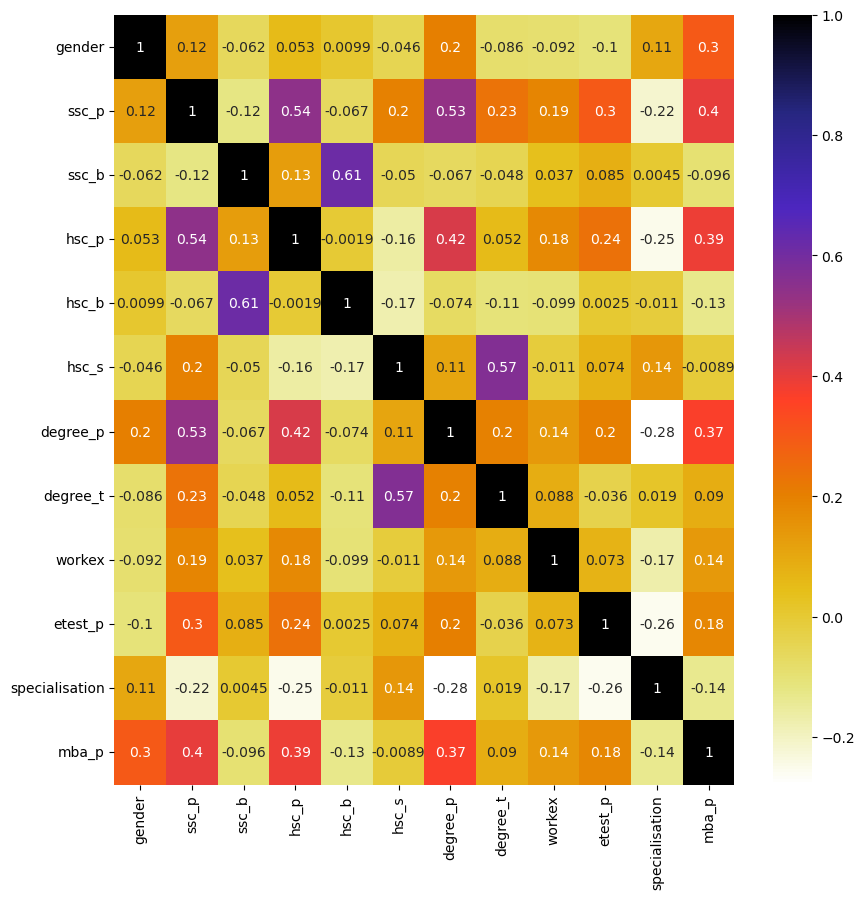

In [39]:
import seaborn as sns
from matplotlib.pyplot import figure
#Using Pearson Correlation
fig = plt.figure(figsize=(10, 10))
cor = x_train.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
# plt.show()

In [40]:
# with the following function we can select highly correlated features
# it will remove the first feature that is correlated with anything other feature

def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [41]:
corr_features = correlation(x_train, 0.9)
len(set(corr_features))

0

In [42]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)
y1 = lr.predict(x_test)

D:\Software_Installation\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
# KNN 
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)
y2 = knn.predict(x_test)

In [44]:
# SVM
from sklearn import svm
svm = svm.SVC()
svm.fit(x_train,y_train)
y3 = svm.predict(x_test)

In [45]:
# DecisionTree Classifier
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
y4 = dt.predict(x_test)

In [46]:
# RandomForest Classifier
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
y5 = rf.predict(x_test)

In [47]:
# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
gb=GradientBoostingClassifier()
gb.fit(x_train,y_train)
y6 = gb.predict(x_test)

## Accuracy Score

In [48]:
from sklearn.metrics import accuracy_score

In [49]:
# Logistic Regression 0.8837209302325582
s1 = accuracy_score(y_test,y1)

In [50]:
# KNN 0.7906976744186046
s2 = accuracy_score(y_test,y2)

In [51]:
# SVM 0.7674418604651163
s3 = accuracy_score(y_test,y3)

In [52]:
# DecisionTree Classifier 0.8372093023255814
s4 =  accuracy_score(y_test,y4)

In [53]:
# RandomForest Classifier 0.7906976744186046
s5 = accuracy_score(y_test,y5)

In [54]:
# Gradient Boosting Classifier 0.813953488372093
s6 = accuracy_score(y_test,y6)

In [55]:
final_data = pd.DataFrame({'Models':['LogisticRegression','KNN','SVM','DecisionTreeClassifier',
                                     'RandomForestClassifier','GradientBoostingClassifier'],
            'ACC':[s1*100,
                  s2*100,
                  s3*100,
                  s4*100,
                  s5*100,s6*100]})

In [56]:
final_data

,Models,ACC
0,LogisticRegression,88.372093
1,KNN,79.069767
2,SVM,76.744186
3,DecisionTreeClassifier,83.720930
4,RandomForestClassifier,79.069767
5,GradientBoostingClassifier,79.069767


In [57]:
final_data['Models']

0            LogisticRegression
1                           KNN
2                           SVM
3        DecisionTreeClassifier
4        RandomForestClassifier
5    GradientBoostingClassifier
Name: Models, dtype: object

In [58]:
import seaborn as sns

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'LogisticRegression'),
  Text(1, 0, 'KNN'),
  Text(2, 0, 'SVM'),
  Text(3, 0, 'DecisionTreeClassifier'),
  Text(4, 0, 'RandomForestClassifier'),
  Text(5, 0, 'GradientBoostingClassifier')])

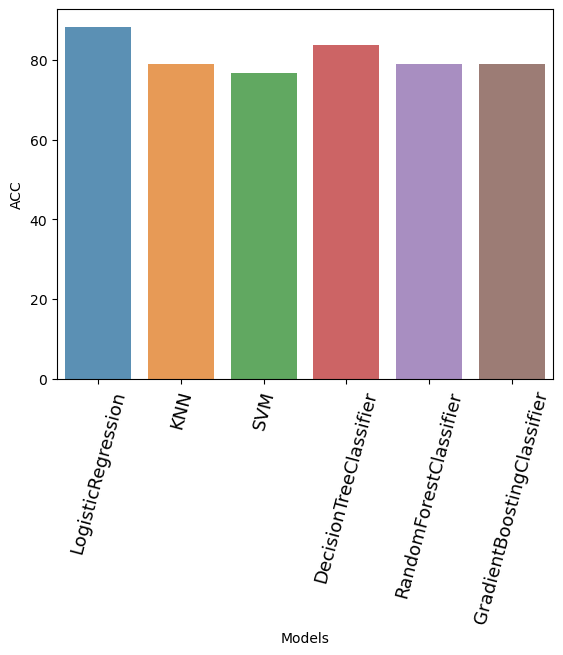

In [59]:
sns.barplot(x=final_data['Models'], y = final_data['ACC'], alpha=0.8)
plt.xticks(rotation = 75, fontsize = 13)

In [60]:
new_data = pd.DataFrame({
    'gender':0,
    'ssc_p':67.0,
    'ssc_b':0,
    'hsc_p':91.0,
    'hsc_b':0,
    'hsc_s':1,
    'degree_p':58.0,
    'degree_t':2,
    'workex':0,
    'etest_p':55.0,
     'specialisation':1,
    'mba_p':58.8,   
},index=[0])

In [61]:
lr= LogisticRegression()
lr.fit(x,y)

D:\Software_Installation\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [62]:
p = lr.predict(new_data)
prob=lr.predict_proba(new_data)
if p == 1:
    print('Placed')
    print(f"You will be placed with probability of {prob[0][1]:.2f}")
else:
    print("Not-placed")

Placed
You will be placed with probability of 0.97


In [63]:
prob

array([[0.03406134, 0.96593866]])

## Model Saving

In [64]:
import joblib

In [65]:
joblib.dump(lr,'model_campus_placement')

['model_campus_placement']

In [66]:
model = joblib.load('model_campus_placement')

In [67]:
model.predict(new_data)

array([1], dtype=int64)